In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

In [41]:
TRAIN_DATA_PATH = "../data/playground-series-s6e2/train.csv"
TEST_DATA_PATH = "../data/playground-series-s6e2/test.csv"

In [42]:
def load_data(path):
    
    if not os.path.exists(path):
        raise FileNotFoundError(f"The file {path} does not exist")
    
    df = pd.read_csv(path)
    
    print("Shape of the dataset:", df.shape, end="\n" + "-"*50 + "\n")
    print("\nFirst 5 rows of the dataset:\n", df.head().to_string(), end="\n" + "-"*50 + "\n")
    print("Data description:\n", df.describe(), end="\n" + "-"*50 + "\n")
    print("\nData types of the columns:\n", df.dtypes, end="\n" + "-"*50 + "\n")
    print("\nColumn names:\n", df.columns, end="\n" + "-"*50 + "\n")
    
    return df

In [43]:
train_df = load_data(TRAIN_DATA_PATH)

Shape of the dataset: (630000, 15)
--------------------------------------------------

First 5 rows of the dataset:
    id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  Max HR  Exercise angina  ST depression  Slope of ST  Number of vessels fluro  Thallium Heart Disease
0   0   58    1                4  152          239             0            0     158                1            3.6            2                        2         7      Presence
1   1   52    1                1  125          325             0            2     171                0            0.0            1                        0         3       Absence
2   2   56    0                2  160          188             0            2     151                0            0.0            1                        0         3       Absence
3   3   44    0                3  134          229             0            2     150                0            1.0            2                        0        

## Exploratory Data Analysis (EDA)

### 1. Gender Distribution

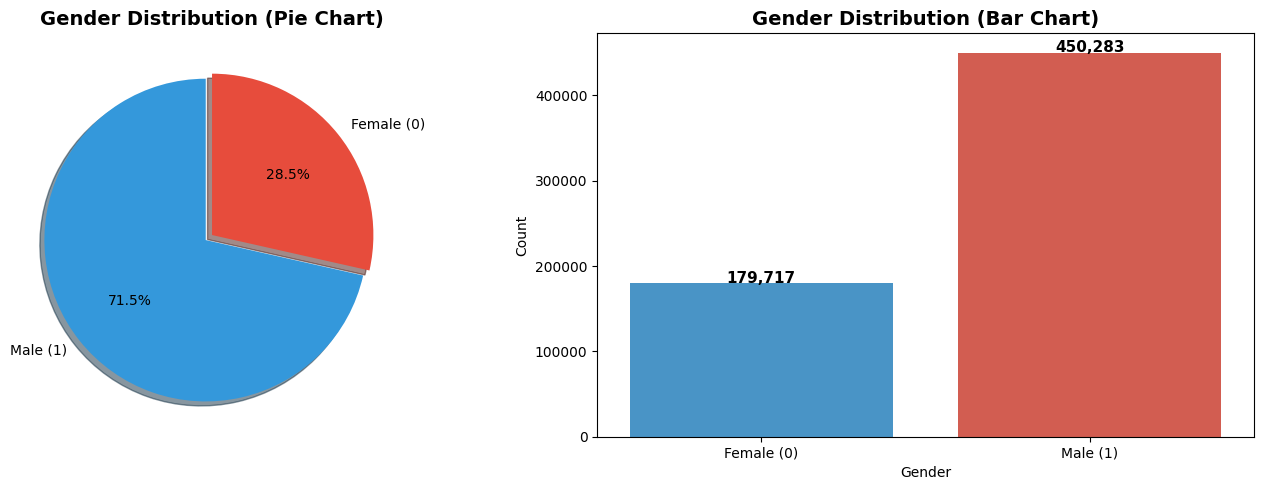

Male count: 450,283 (71.5%)
Female count: 179,717 (28.5%)


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
gender_counts = train_df['Sex'].value_counts()
labels = ['Male (1)', 'Female (0)']
colors = ['#3498db', '#e74c3c']
explode = (0.05, 0)
axes[0].pie(gender_counts, labels=labels, autopct='%1.1f%%', colors=colors, 
            explode=explode, shadow=True, startangle=90)
axes[0].set_title('Gender Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=train_df, x='Sex', palette=colors, ax=axes[1], hue='Sex', legend=False)
axes[1].set_xticklabels(['Female (0)', 'Male (1)'])
axes[1].set_title('Gender Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

# Add count labels on bars
for i, count in enumerate(gender_counts.sort_index()):
    axes[1].text(i, count + 1000, f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Male count: {gender_counts[1]:,} ({gender_counts[1]/len(train_df)*100:.1f}%)")
print(f"Female count: {gender_counts[0]:,} ({gender_counts[0]/len(train_df)*100:.1f}%)")

### 2. Age Distribution

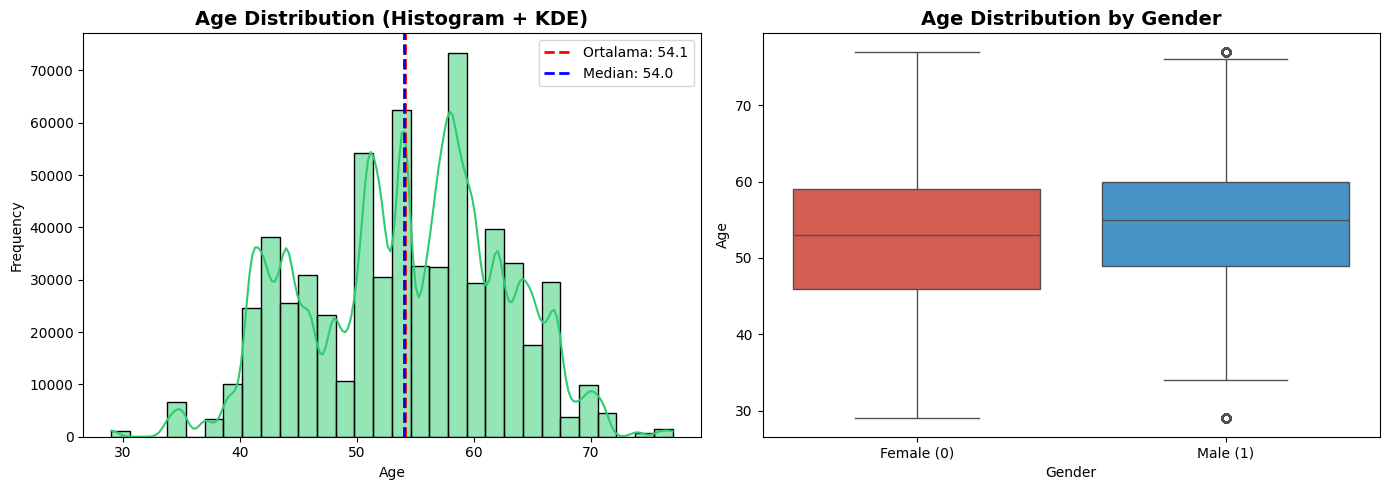

Age statistics:
  Min: 29, Max: 77
  Mean: 54.14, Median: 54.0
  Std Dev: 8.26


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(data=train_df, x='Age', bins=30, kde=True, color='#2ecc71', ax=axes[0])
axes[0].axvline(train_df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Ortalama: {train_df['Age'].mean():.1f}")
axes[0].axvline(train_df['Age'].median(), color='blue', linestyle='--', linewidth=2, label=f"Median: {train_df['Age'].median():.1f}")
axes[0].set_title('Age Distribution (Histogram + KDE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot by gender
sns.boxplot(data=train_df, x='Sex', y='Age', palette=['#e74c3c', '#3498db'], ax=axes[1], hue='Sex', legend=False)
axes[1].set_xticklabels(['Female (0)', 'Male (1)'])
axes[1].set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print(f"Age statistics:")
print(f"  Min: {train_df['Age'].min()}, Max: {train_df['Age'].max()}")
print(f"  Mean: {train_df['Age'].mean():.2f}, Median: {train_df['Age'].median()}")
print(f"  Std Dev: {train_df['Age'].std():.2f}")

### 3. Age vs Cholesterol Distribution

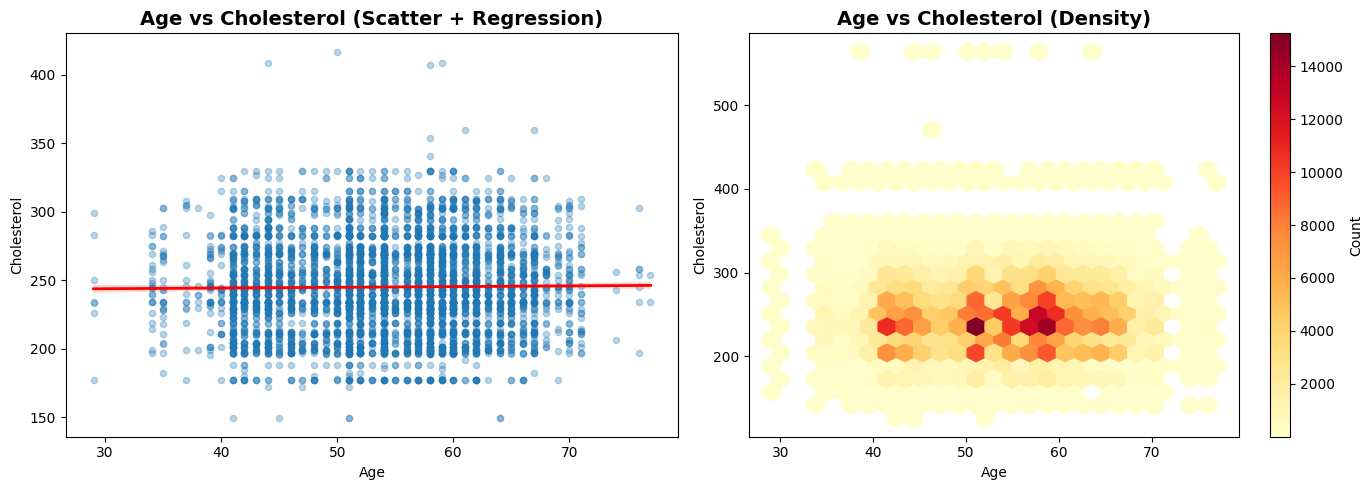

Age-Cholesterol Correlation: 0.0195


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with regression line
sample_df = train_df.sample(n=5000, random_state=42)  # Sample for visibility
sns.regplot(data=sample_df, x='Age', y='Cholesterol', scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'red', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('Age vs Cholesterol (Scatter + Regression)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Cholesterol')

# Hexbin plot for density visualization
hb = axes[1].hexbin(train_df['Age'], train_df['Cholesterol'], gridsize=25, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Age vs Cholesterol (Density)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Cholesterol')
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

correlation = train_df['Age'].corr(train_df['Cholesterol'])
print(f"Age-Cholesterol Correlation: {correlation:.4f}")

### 4. Correlation Heatmap

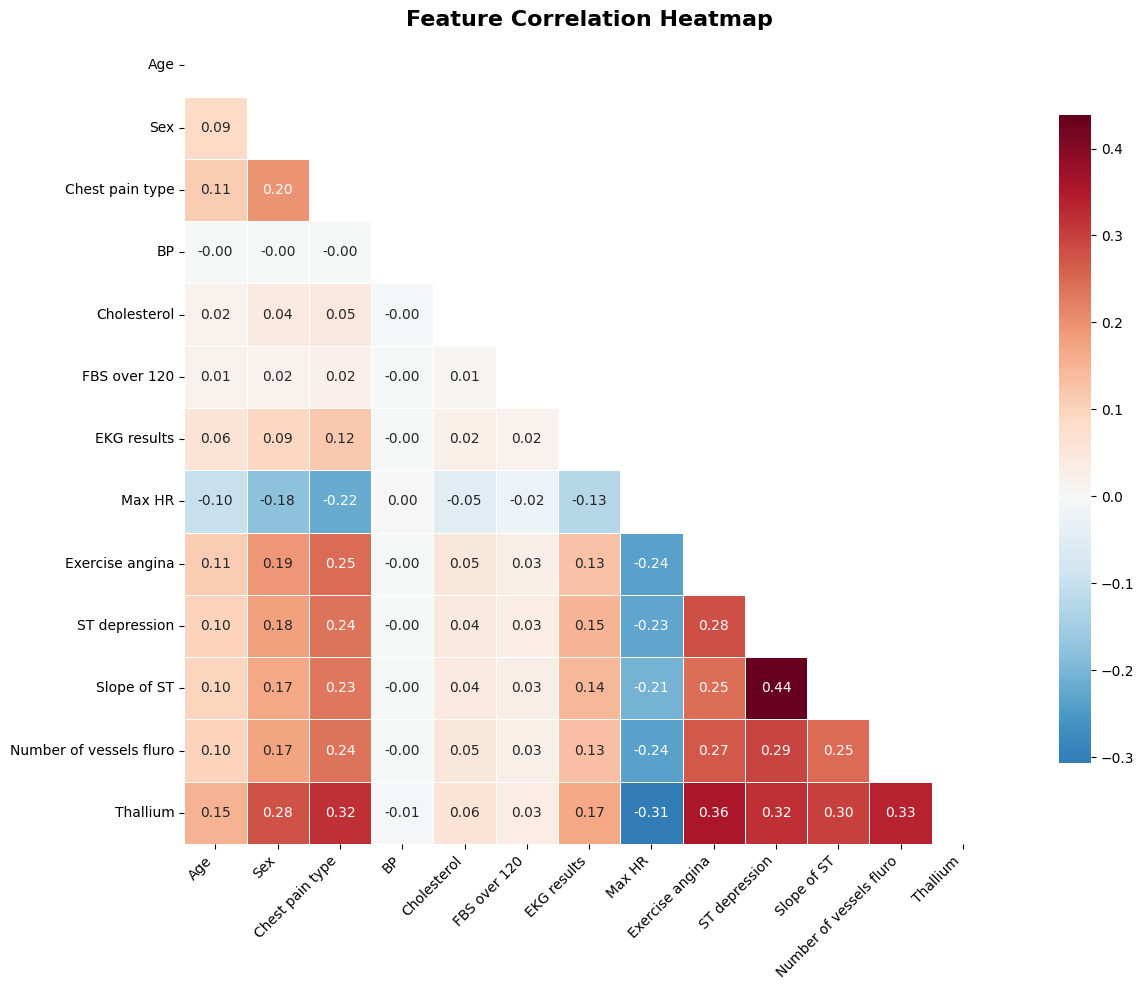


Top positive correlations:
Slope of ST              ST depression              0.438240
ST depression            Slope of ST                0.438240
Thallium                 Exercise angina            0.357076
Exercise angina          Thallium                   0.357076
Thallium                 Number of vessels fluro    0.333460
Number of vessels fluro  Thallium                   0.333460
Thallium                 Chest pain type            0.319887
Chest pain type          Thallium                   0.319887
ST depression            Thallium                   0.316891
Thallium                 ST depression              0.316891


In [47]:
# Select numeric columns only (exclude 'id')
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.drop('id')
corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop positive correlations:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Exclude self-correlation
print(corr_pairs.head(10).to_string())

### 5. Target Variable Distribution (Heart Disease)

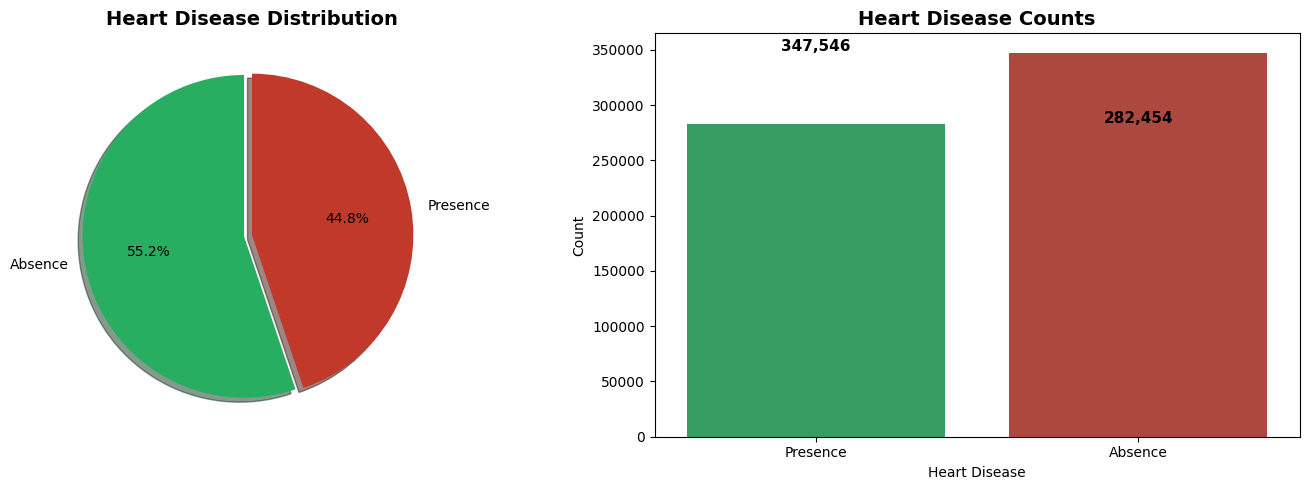

Class distribution:
  Absence: 347,546 (55.2%)
  Presence: 282,454 (44.8%)


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
target_counts = train_df['Heart Disease'].value_counts()
colors = ['#27ae60', '#c0392b']

# Pie chart
axes[0].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.05, 0), shadow=True, startangle=90)
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=train_df, x='Heart Disease', palette=colors, ax=axes[1], hue='Heart Disease', legend=False)
axes[1].set_title('Heart Disease Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Count')

for i, (label, count) in enumerate(target_counts.items()):
    axes[1].text(i, count + 1000, f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class distribution:")
for label, count in target_counts.items():
    print(f"  {label}: {count:,} ({count/len(train_df)*100:.1f}%)")

### 6. Feature Distributions by Heart Disease

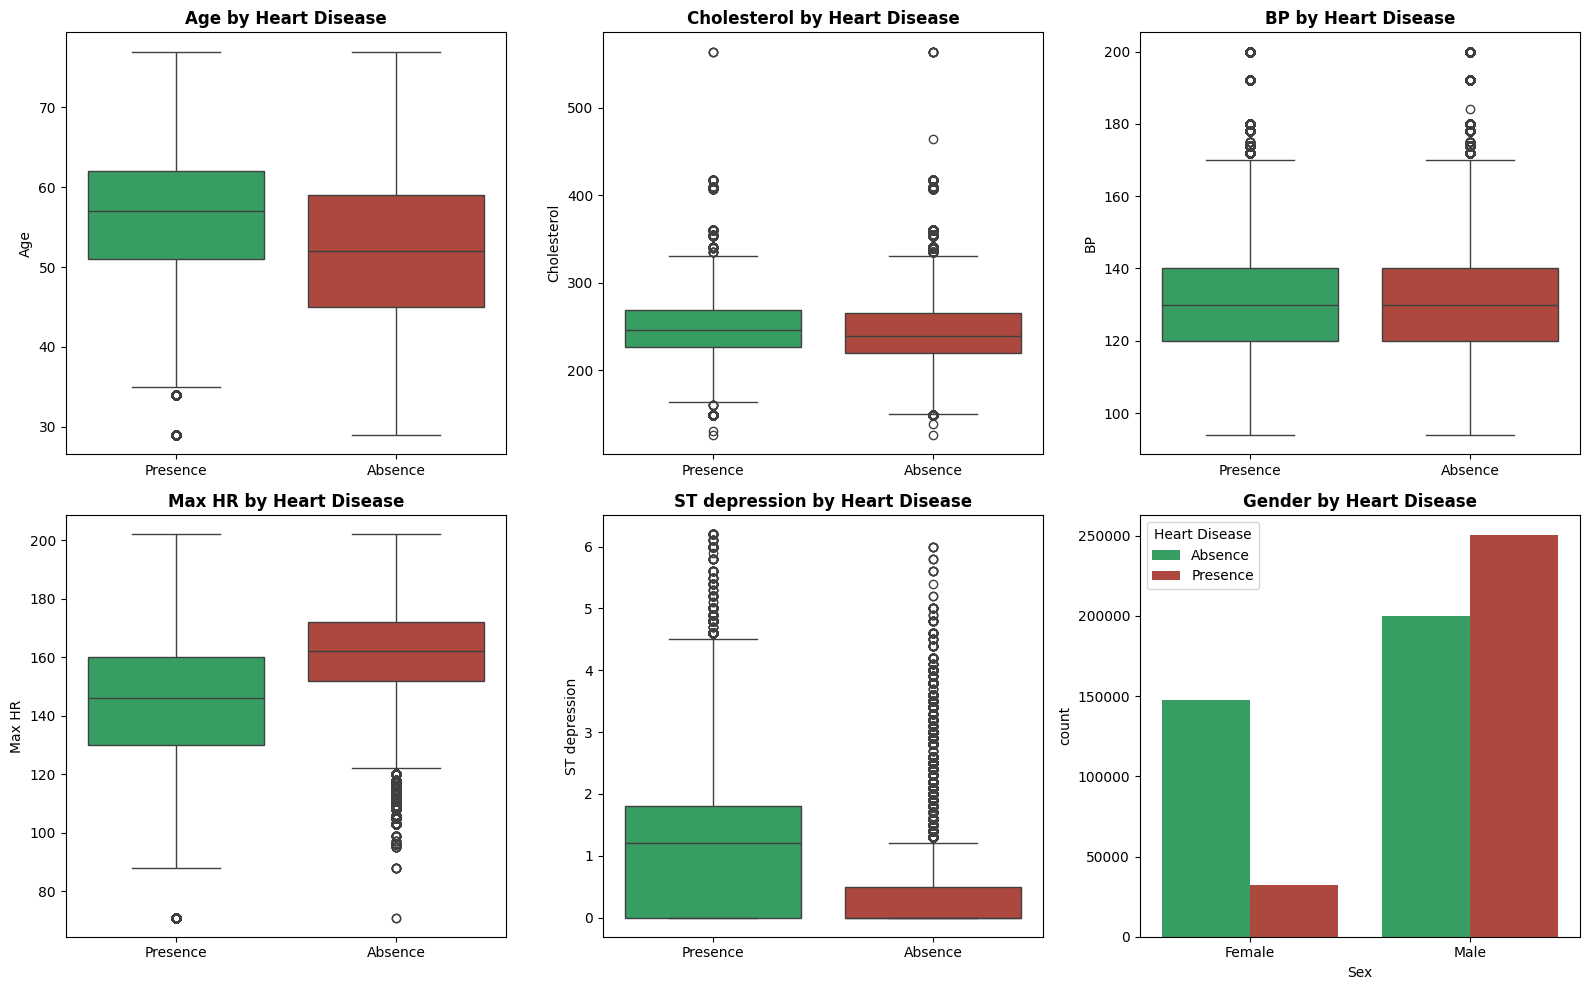

In [49]:
# Key features to analyze
features = ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=train_df, x='Heart Disease', y=feature, 
                palette=['#27ae60', '#c0392b'], ax=axes[i], hue='Heart Disease', legend=False)
    axes[i].set_title(f'{feature} by Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# Gender distribution by Heart Disease
sns.countplot(data=train_df, x='Sex', hue='Heart Disease', 
              palette=['#27ae60', '#c0392b'], ax=axes[5])
axes[5].set_xticklabels(['Female', 'Male'])
axes[5].set_title('Gender by Heart Disease', fontsize=12, fontweight='bold')
axes[5].legend(title='Heart Disease')

plt.tight_layout()
plt.show()

### 7. Violin Plots - Detailed Distribution Analysis

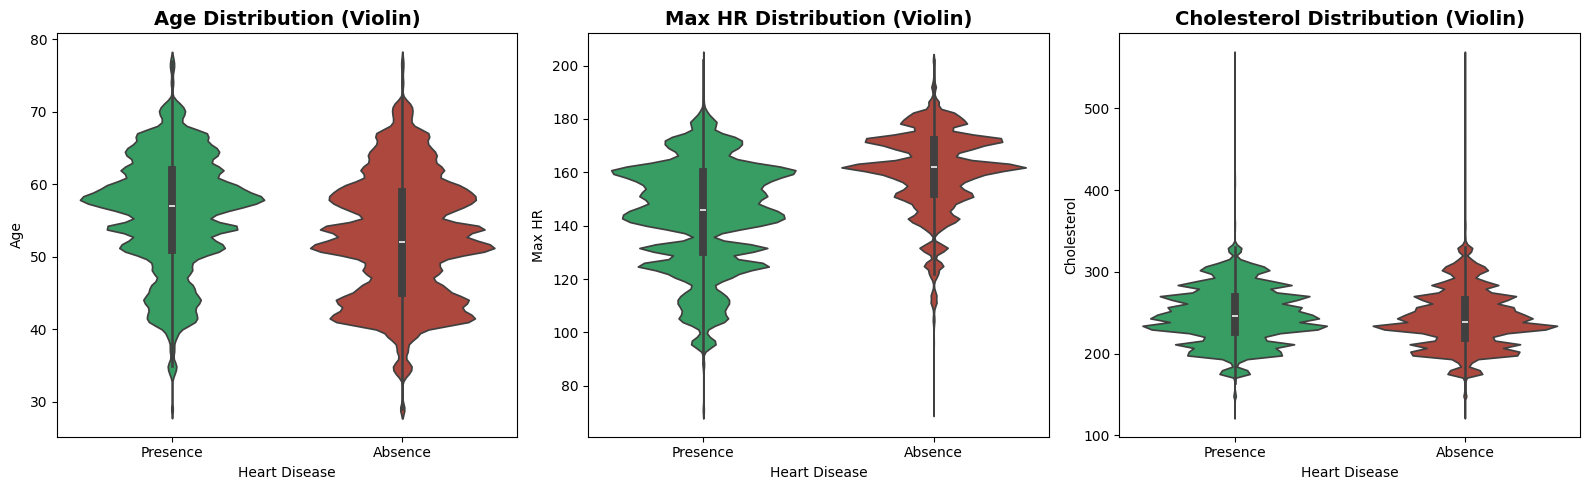

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age violin plot
sns.violinplot(data=train_df, x='Heart Disease', y='Age', 
               palette=['#27ae60', '#c0392b'], ax=axes[0], hue='Heart Disease', legend=False)
axes[0].set_title('Age Distribution (Violin)', fontsize=14, fontweight='bold')

# Max HR violin plot
sns.violinplot(data=train_df, x='Heart Disease', y='Max HR', 
               palette=['#27ae60', '#c0392b'], ax=axes[1], hue='Heart Disease', legend=False)
axes[1].set_title('Max HR Distribution (Violin)', fontsize=14, fontweight='bold')

# Cholesterol violin plot
sns.violinplot(data=train_df, x='Heart Disease', y='Cholesterol', 
               palette=['#27ae60', '#c0392b'], ax=axes[2], hue='Heart Disease', legend=False)
axes[2].set_title('Cholesterol Distribution (Violin)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 8. Categorical Variable Analysis

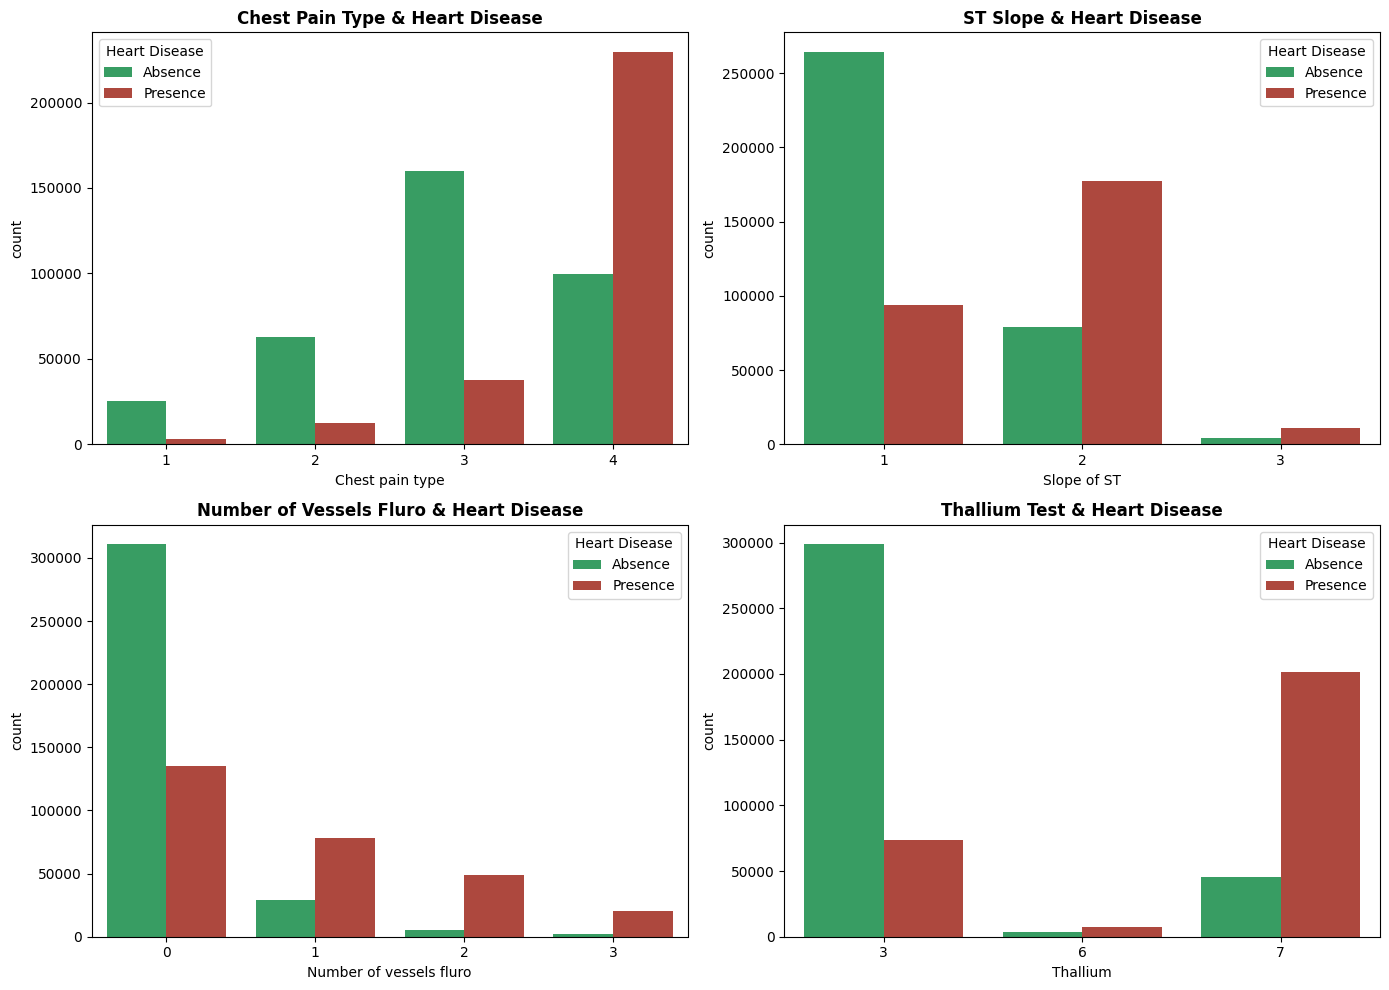

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chest pain type distribution
sns.countplot(data=train_df, x='Chest pain type', hue='Heart Disease', 
              palette=['#27ae60', '#c0392b'], ax=axes[0, 0])
axes[0, 0].set_title('Chest Pain Type & Heart Disease', fontsize=12, fontweight='bold')
axes[0, 0].legend(title='Heart Disease')

# Slope of ST
sns.countplot(data=train_df, x='Slope of ST', hue='Heart Disease', 
              palette=['#27ae60', '#c0392b'], ax=axes[0, 1])
axes[0, 1].set_title('ST Slope & Heart Disease', fontsize=12, fontweight='bold')
axes[0, 1].legend(title='Heart Disease')

# Number of vessels fluro
sns.countplot(data=train_df, x='Number of vessels fluro', hue='Heart Disease', 
              palette=['#27ae60', '#c0392b'], ax=axes[1, 0])
axes[1, 0].set_title('Number of Vessels Fluro & Heart Disease', fontsize=12, fontweight='bold')
axes[1, 0].legend(title='Heart Disease')

# Thallium
sns.countplot(data=train_df, x='Thallium', hue='Heart Disease', 
              palette=['#27ae60', '#c0392b'], ax=axes[1, 1])
axes[1, 1].set_title('Thallium Test & Heart Disease', fontsize=12, fontweight='bold')
axes[1, 1].legend(title='Heart Disease')

plt.tight_layout()
plt.show()

### 9. Pair Plot - Multi-Variable Relationships

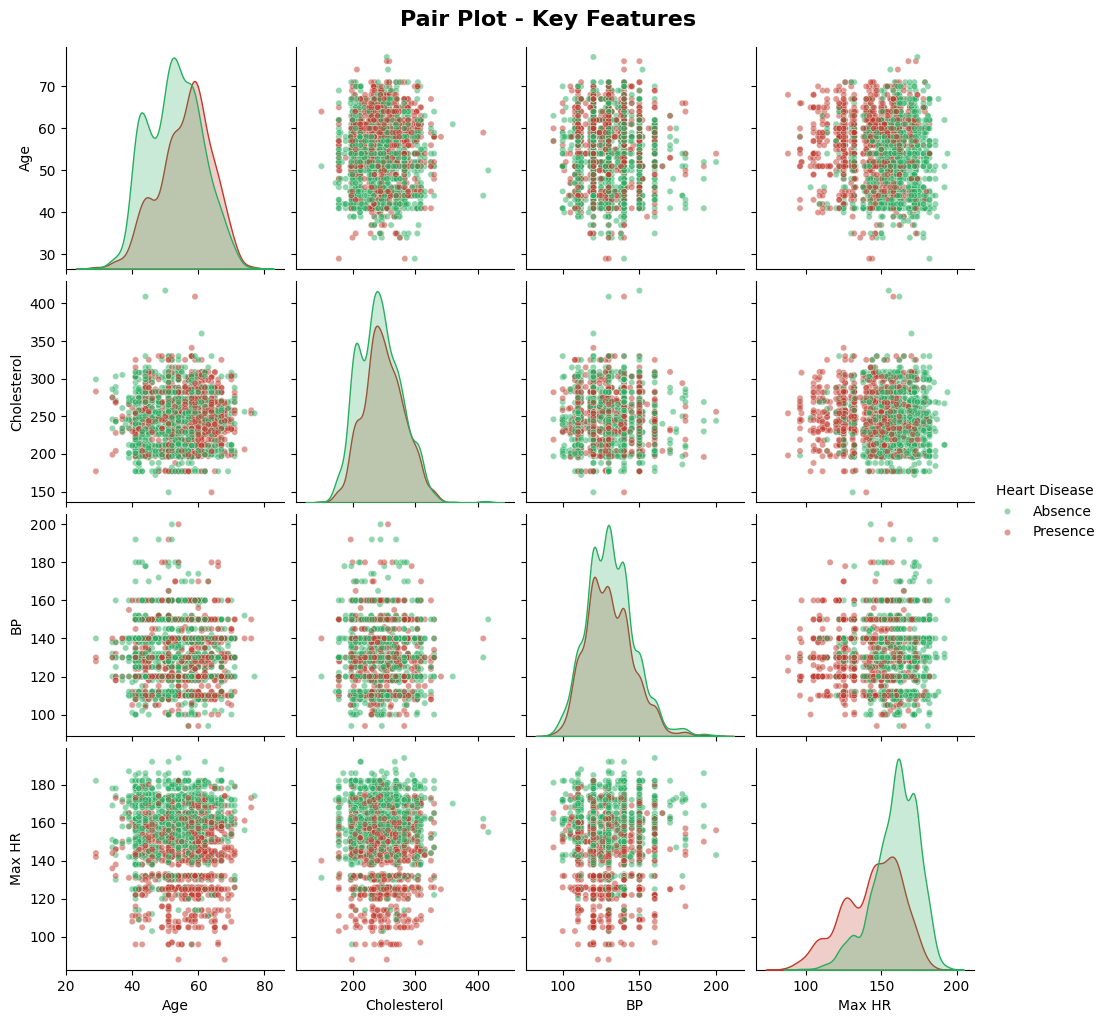

In [52]:
# Sample for faster plotting
sample_size = 2000
sample_df = train_df.sample(n=sample_size, random_state=42)

selected_features = ['Age', 'Cholesterol', 'BP', 'Max HR', 'Heart Disease']
g = sns.pairplot(sample_df[selected_features], hue='Heart Disease', 
                 palette=['#27ae60', '#c0392b'], diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Pair Plot - Key Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### 10. Missing Data Analysis

In [53]:
# Check for missing values
missing_data = train_df.isnull().sum()
missing_pct = (missing_data / len(train_df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_pct
})

print("Missing Data Analysis:")
print("="*50)
print(missing_df.to_string())
print(f"\nTotal missing values: {missing_data.sum()}")

if missing_data.sum() > 0:
    plt.figure(figsize=(12, 5))
    missing_data[missing_data > 0].plot(kind='bar', color='#e74c3c')
    plt.title('Missing Data Counts', fontsize=14, fontweight='bold')
    plt.ylabel('Missing Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in dataset!")

Missing Data Analysis:
                         Missing Count  Missing %
id                                   0        0.0
Age                                  0        0.0
Sex                                  0        0.0
Chest pain type                      0        0.0
BP                                   0        0.0
Cholesterol                          0        0.0
FBS over 120                         0        0.0
EKG results                          0        0.0
Max HR                               0        0.0
Exercise angina                      0        0.0
ST depression                        0        0.0
Slope of ST                          0        0.0
Number of vessels fluro              0        0.0
Thallium                             0        0.0
Heart Disease                        0        0.0

Total missing values: 0

✓ No missing values found in dataset!
